In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
from PIL import Image
from tqdm.notebook import tqdm
import random
from matplotlib import pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

cuda


In [2]:
from google.colab import files #
file_uploaded=files.upload()

Saving apple.zip to apple.zip


In [3]:
!unzip apple.zip

Archive:  apple.zip
   creating: blotch/
  inflating: blotch/blotch.0.jpg     
  inflating: blotch/blotch.1.jpg     
  inflating: blotch/blotch.2.jpg     
  inflating: blotch/blotch.3.jpg     
  inflating: blotch/blotch.4.jpg     
  inflating: blotch/blotch.5.jpg     
  inflating: blotch/blotch.6.jpg     
  inflating: blotch/blotch.7.jpg     
  inflating: blotch/blotch.8.jpg     
  inflating: blotch/blotch.9.jpg     
  inflating: blotch/blotch.10.jpg    
  inflating: blotch/blotch.11.jpg    
  inflating: blotch/blotch.12.jpg    
  inflating: blotch/blotch.13.jpg    
  inflating: blotch/blotch.14.jpg    
  inflating: blotch/blotch.15.jpg    
  inflating: blotch/blotch.16.jpg    
  inflating: blotch/blotch.17.jpg    
  inflating: blotch/blotch.18.jpg    
  inflating: blotch/blotch.19.jpg    
  inflating: blotch/blotch.20.jpg    
  inflating: blotch/blotch.21.jpg    
  inflating: blotch/blotch.22.jpg    
  inflating: blotch/blotch.23.jpg    
  inflating: blotch/blotch.24.jpg    
  inflati

In [7]:
blotch_directory = 'blotch/'
normal_directory = 'normal/'
rot_directory = 'rot/'
scab_directory = 'scab/'


blotch_images_filepaths = sorted([os.path.join(blotch_directory, f) for f in os.listdir(blotch_directory)])
normal_images_filepaths = sorted([os.path.join(normal_directory, f) for f in os.listdir(normal_directory)])
rot_images_filepaths = sorted([os.path.join(rot_directory, f) for f in os.listdir(rot_directory)])
scab_images_filepaths = sorted([os.path.join(scab_directory, f) for f in os.listdir(scab_directory)])
images_filepaths = [*blotch_images_filepaths, *normal_images_filepaths, *rot_images_filepaths, *scab_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

In [6]:
blotch_directory = 'test/blotch/'
normal_directory = 'test/normal/'
rot_directory = 'test/rot/'
scab_directory = 'test/scab/'


blotch_images_filepaths = sorted([os.path.join(blotch_directory, f) for f in os.listdir(blotch_directory)])
normal_images_filepaths = sorted([os.path.join(normal_directory, f) for f in os.listdir(normal_directory)])
rot_images_filepaths = sorted([os.path.join(rot_directory, f) for f in os.listdir(rot_directory)])
scab_images_filepaths = sorted([os.path.join(scab_directory, f) for f in os.listdir(scab_directory)])
images_filepaths = [*blotch_images_filepaths, *normal_images_filepaths, *rot_images_filepaths, *scab_images_filepaths]
test_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

FileNotFoundError: [Errno 2] No such file or directory: 'test/blotch/'

In [8]:
print(len(correct_images_filepaths))

320


In [9]:
from numpy.lib import test
random.seed(1)
random.shuffle(correct_images_filepaths)

train_images_filepaths = correct_images_filepaths[:290]
val_images_filepaths = correct_images_filepaths[290:]
test_images_filepaths = correct_images_filepaths[-10:]
print('train:', len(train_images_filepaths))
print('val:', len(val_images_filepaths))
print('test:', len(test_images_filepaths))

print(train_images_filepaths)

train: 290
val: 30
test: 10
['rot/rot.43.jpg', 'rot/rot.55.jpg', 'rot/rot.68.jpg', 'rot/rot.75.jpg', 'rot/rot.41.jpg', 'rot/rot.30.jpg', 'blotch/blotch.72.jpg', 'rot/rot.62.jpg', 'rot/rot.79.jpg', 'blotch/blotch.36.jpg', 'normal/normal.23.jpg', 'blotch/blotch.42.jpg', 'rot/rot.47.jpg', 'scab/scab.39.jpg', 'normal/normal.8.jpg', 'rot/rot.36.jpg', 'normal/normal.30.jpg', 'scab/scab.31.jpg', 'scab/scab.2.jpg', 'rot/rot.9.jpg', 'normal/normal.26.jpg', 'normal/normal.1.jpg', 'blotch/blotch.26.jpg', 'blotch/blotch.53.jpg', 'rot/rot.20.jpg', 'rot/rot.76.jpg', 'rot/rot.74.jpg', 'scab/scab.65.jpg', 'scab/scab.66.jpg', 'normal/normal.34.jpg', 'normal/normal.37.jpg', 'normal/normal.50.jpg', 'normal/normal.62.jpg', 'scab/scab.61.jpg', 'scab/scab.38.jpg', 'blotch/blotch.6.jpg', 'blotch/blotch.4.jpg', 'scab/scab.21.jpg', 'blotch/blotch.40.jpg', 'rot/rot.65.jpg', 'blotch/blotch.65.jpg', 'rot/rot.24.jpg', 'scab/scab.6.jpg', 'blotch/blotch.78.jpg', 'normal/normal.28.jpg', 'rot/rot.14.jpg', 'blotch/blot

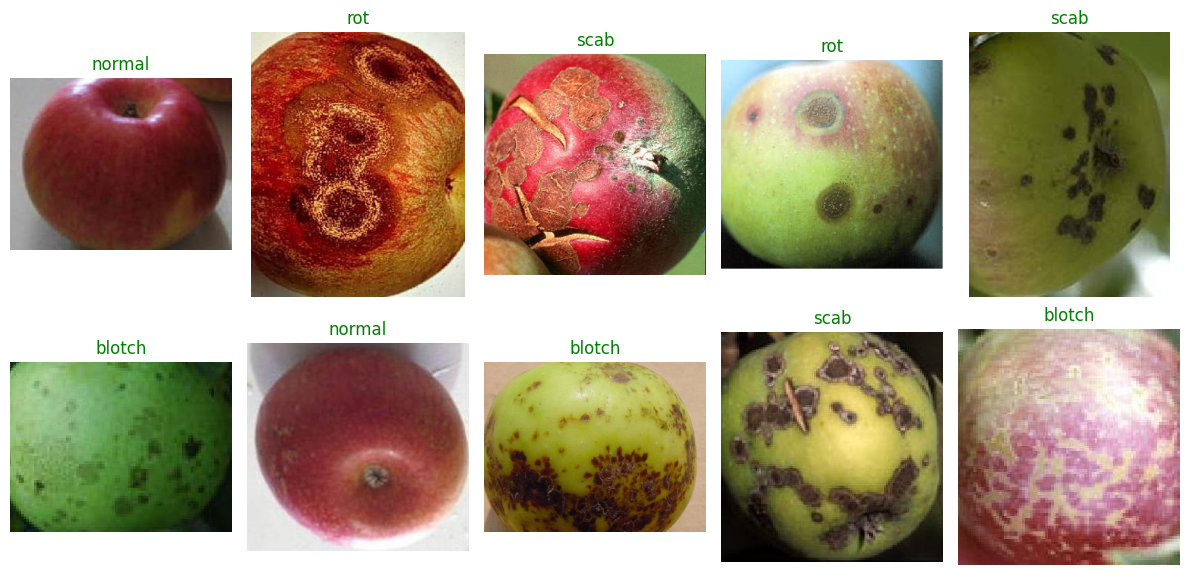

In [10]:
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        true_label = os.path.normpath(image_filepath).split(os.sep)[-2]
        predicted_label = predicted_labels[i] if predicted_labels else true_label
        color = "green" if true_label == predicted_label else "red"
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(predicted_label, color=color)
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()
display_image_grid(test_images_filepaths)

In [11]:
class AppleDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0] # for example, bloth.75.jpg -> blotch
        if label == 'blotch':
            label = 0
        elif label == 'normal':
            label = 1
        if label == 'rot':
            label = 2
        elif label == 'scab':
            label = 3
        return img_transformed, label

In [12]:
size = 256
mean = (0.485, 0.456, 0.406) # RGB
std = (0.229, 0.224, 0.225) #RGB
batch_size = 32
train_dataset = AppleDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
test_dataset = AppleDataset(test_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
print('image size:', train_dataset.__getitem__(index)[0].size())
print('image label:', train_dataset.__getitem__(index)[1])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

image size: torch.Size([3, 256, 256])
image label: 2
torch.Size([32, 3, 256, 256])
tensor([0, 2, 1, 0, 1, 1, 3, 0, 1, 1, 3, 2, 3, 1, 3, 0, 0, 3, 2, 2, 2, 3, 1, 1,
        2, 2, 3, 2, 0, 2, 0, 0])


In [13]:
import torchvision.models as models
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


In [14]:
model.fc = nn.Linear(512, 4)

for param in model.fc.parameters():
    param.requires_grad = True

In [15]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

fc.weight tensor([[ 1.9668e-02,  4.3400e-02,  7.6632e-03,  ...,  5.9323e-03,
          3.1023e-02, -1.5033e-02],
        [-3.4311e-02,  3.0459e-02, -4.7788e-03,  ..., -3.1205e-02,
          1.0819e-02, -3.1387e-02],
        [-7.0232e-05, -3.9841e-02,  4.4112e-02,  ...,  2.0033e-02,
          2.8848e-02, -3.3853e-02],
        [-1.8933e-02,  4.3736e-02, -3.2570e-02,  ..., -4.0623e-02,
          2.1840e-02, -1.4495e-02]])
fc.bias tensor([-0.0258, -0.0308, -0.0112,  0.0014])


In [16]:
optimizer = torch.optim.Adam(model.fc.parameters())
criterion = torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:

model = model.to(device)
criterion = criterion.to(device)
import time

def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch):
        print('Epoch {}/{}'.format(epoch + 1, num_epoch))
        print('-'*20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            epoch_loss = 0.0
            epoch_corrects = 0

            for inputs, labels in tqdm(dataloader_dict[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    epoch_loss += loss.item() * inputs.size(0)
                    epoch_corrects += torch.sum(preds == labels.data)

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)
            epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    return model

In [19]:
num_epoch = 50
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/50
--------------------


  0%|          | 0/10 [00:00<?, ?it/s]

train Loss: 1.4174 Acc: 0.2862


  0%|          | 0/1 [00:00<?, ?it/s]

val Loss: 1.1516 Acc: 0.5000
Epoch 2/50
--------------------


...

val Loss: 0.4983 Acc: 0.7000
Epoch 50/50
--------------------


  0%|          | 0/10 [00:00<?, ?it/s]

train Loss: 0.2654 Acc: 0.9310


  0%|          | 0/1 [00:00<?, ?it/s]

val Loss: 0.5095 Acc: 0.7000
Training complete in 1m 38s
Best val Acc: 0.900000


In [20]:
import pandas as pd

corrects = 0
_id=0

with torch.no_grad():
    for test_path in tqdm(test_images_filepaths):
        img = Image.open(test_path)
        _id =test_path.split('/')[-1].split('.')[1]
        if test_path.split('/')[-1].split('.')[0] == 'blotch':
            label = 0
        elif test_path.split('/')[-1].split('.')[0] == 'normal':
            label = 1
        elif test_path.split('/')[-1].split('.')[0] == 'rot':
            label = 2
        else:
            label = 3
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        corrects += torch.sum(preds == label)

acc = (corrects / len(test_images_filepaths)).cpu().numpy()
print('Test Acc: {:4f}'.format(acc ))


  0%|          | 0/10 [00:00<?, ?it/s]

Test Acc: 0.700000
